# Analysis Notebook

# Setup

In [ ]:

options(warn = -1)

packages <- c("DT","car","glmmTMB","AICcmodavg", "ggeffects","DHARMa", "brms", "emmeans", "lme4","lmerTest","vegan","ggnewscale","multcompView","patchwork","janitor","lubridate","stringr","tidyverse","dplyr","ggplot2","readxl","writexl","readr")

# Load packages if not already installed
quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

invisible(lapply(packages, quiet_load))

exc_file_dir <- "data/raw/NCE_data.xlsx"
der_data_dir <- "data/derived"
out_dir      <- "outputs"

# Read sheets from raw xlsx
df_NCE_raw <- readxl::read_excel(exc_file_dir, sheet = "NCE_exp")
df_Feeding_raw <- readxl::read_excel(exc_file_dir, sheet = "Feeding")

# Save as csv to derived/
write.csv(df_NCE_raw,     file.path(der_data_dir, "NCE_exp.csv"),  row.names = FALSE)
write.csv(df_Feeding_raw, file.path(der_data_dir, "Feeding.csv"),  row.names = FALSE)

df_NCE_raw     <- read.csv(file.path(der_data_dir, "NCE_exp.csv"))
df_Feeding_raw <- read.csv(file.path(der_data_dir, "Feeding.csv"))

# Set base for plots
base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "Arial", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3))
theme_set(base_theme_bw)


# Refuge experiment

## Build refuge dataframe

In [ ]:

df_NCE_raw <- df_NCE_raw %>%
  dplyr::select(-location_T180, -behaviour_T180)

# make into long format
koura_long <- df_NCE_raw %>%
  pivot_longer(
    cols = matches("^(location|behaviour)_"),
    names_to   = c(".value","time"),
    names_pattern = "(location|behaviour)_T?(\\d+)" ) %>%
  mutate(time = as.numeric(time))

koura_long <- koura_long %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

#Group all refuge used
koura_long_ref <- koura_long %>%
  mutate(
    location = case_when(
      location %in% c("floor", "wall", "barrier") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_))

koura_long_ref <- koura_long_ref %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))


## Refuge table

In [ ]:

prop_refuge_light_treat <- koura_long_ref %>%
  dplyr::group_by(light, treatment, period) %>%
  dplyr::summarise(
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_treat <- koura_long_ref %>%
  dplyr::group_by(treatment, period) %>%
  dplyr::summarise(light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_light <- koura_long_ref %>%
  dplyr::group_by(light, period) %>%
  dplyr::summarise(treatment = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_per <- koura_long_ref %>%
  dplyr::group_by(period) %>%
  dplyr::summarise(treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_comb <- koura_long_ref %>%
  dplyr::summarise(period = "combined",
    treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

refuge_table <- dplyr::bind_rows(prop_refuge_light_treat, prop_refuge_treat,prop_refuge_light, prop_refuge_per, prop_refuge_comb) %>%
  mutate_if(is.numeric, round, digits = 2)

# extract specific values for inline reporting
get_prop <- function(l, t, p) {
  refuge_table %>% 
    filter(light == l, treatment == t, period == p) %>% 
    pull(prop_refuge)
}

write.csv(refuge_table, file = file.path(out_dir, "refuge_table.csv"), row.names = FALSE)

if (knitr::is_html_output()) {
  datatable(
    refuge_table,
    caption = "Proportion of kōura observations recorded in refuge across experimental treatments (catfish, eel, control), light conditions (light, dark), and periods (before, during, and after predator exposure). Combined rows summarise across all levels of a given factor. Values represent the proportion of total observations where kōura were located in the refuge.",
    filter = "top",
    options = list(
      pageLength = 37,
      dom = 'Bfrtip',
      buttons = c('csv', 'excel'),
      columnDefs = list(list(className = 'dt-center', targets = "_all"))
    ),
    extensions = 'Buttons',
    rownames = FALSE,
    colnames = c("Light", "Treatment", "Period", "N total", "N refuge", "Proportion in refuge")
  ) |>
    formatRound(columns = "prop_refuge", digits = 2) |>
    formatStyle(
      "prop_refuge",
      background = styleColorBar(range(refuge_table$prop_refuge), "lightblue"),
      backgroundSize = "100% 90%",
      backgroundRepeat = "no-repeat",
      backgroundPosition = "center"
    )
} else {
  knitr::kable(refuge_table, digits = 2,
    caption = "Proportion of kōura observations in refuge by treatment, light condition and period")
}


## Refuge plot

systemfonts and textshaping have been compiled with different versions of Freetype. Because of this, textshaping will not use the font cache provided by systemfonts

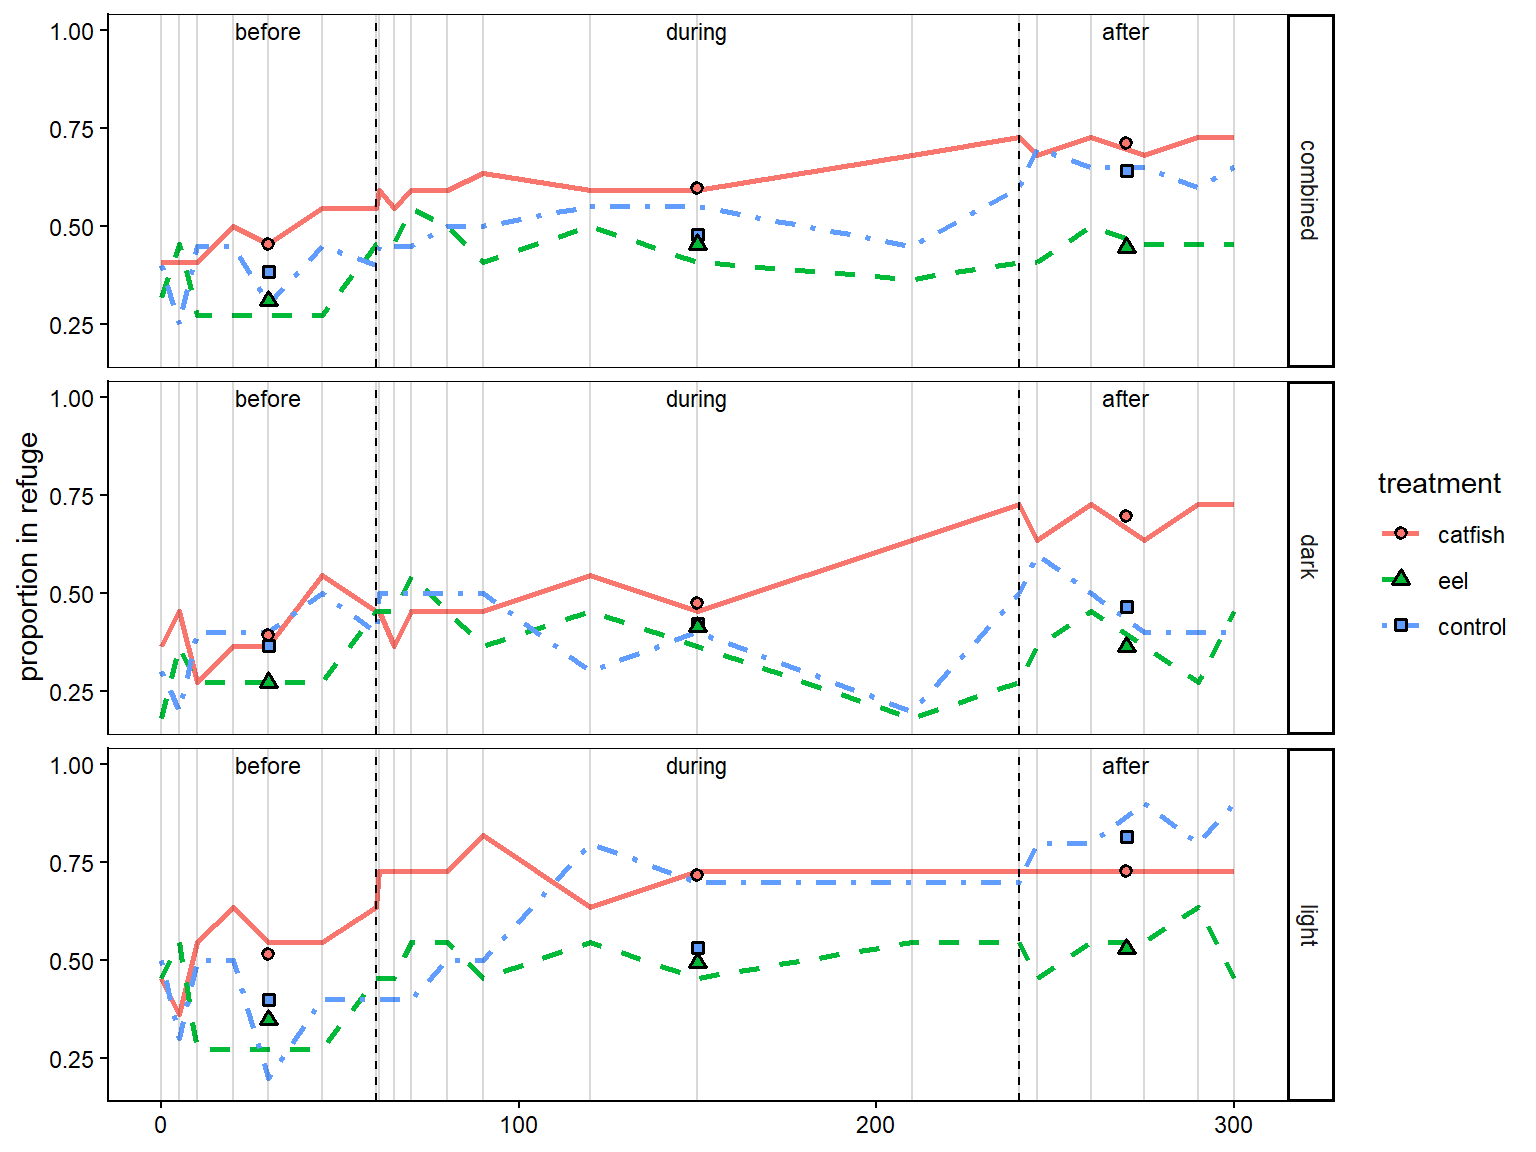

In [ ]:

loc_order_ref <- c("refuge","open")

# calculate the proportions of location for each treatment for each time step
prop_location_time <- koura_long_ref %>%
  filter(!is.na(location), location != "") %>%
  count(treatment, time, light, location = location, name = "n") %>%
  group_by(treatment, time, light) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
    location  = factor(location,  levels = loc_order_ref))

# Create combined light data
prop_location_time_combined <- prop_location_time %>%
  group_by(treatment, time, location) %>%
  summarise(n = sum(n), .groups = "drop") %>%
  group_by(treatment, time) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(light = "combined")

period_x <- c("before" = 30, "during" = 150, "after" = 270)

prop_overlay <- prop_refuge_light_treat %>%
  mutate(time = period_x[period], treatment = factor(treatment, levels = c("catfish", "eel", "control")))

prop_overlay_combined <- prop_refuge_treat %>%
  mutate(time = period_x[period], 
         treatment = factor(treatment, levels = c("catfish", "eel", "control")))

# Bind combined with separated
plot_data <- bind_rows(prop_location_time, prop_location_time_combined) %>%
  mutate(light = factor(light, levels = c("combined", "dark", "light")))

overlay_data <- bind_rows(prop_overlay, prop_overlay_combined) %>%
  mutate(light = factor(light, levels = c("combined", "dark", "light")))

refuge_plot <- plot_data %>%
  dplyr::filter(location == "refuge") %>%
  ggplot2::ggplot(aes(time, prop, colour = treatment, group = treatment, linetype = treatment)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  geom_vline(xintercept = c(0, 5, 10, 20, 30, 45, 60, 61, 65, 70, 80, 90, 120, 150, 210, 240, 245, 260, 275, 290, 300), alpha = .15) +
  geom_point(data = overlay_data,  aes(x = time, y = prop_refuge, fill = treatment, shape = treatment), stroke = 1, col = "black") +
  annotate("text", x = 30,  y = 1, label = "before", size = 3) +
  annotate("text", x = 150, y = 1, label = "during", size = 3) +
  annotate("text", x = 270, y = 1, label = "after",  size = 3) +
  scale_linetype_manual(values = c("solid", "dashed", "dotdash")) +
  scale_shape_manual(values = c(21, 24, 22)) +
  facet_grid(light ~ ., scales = "free_x") +
  labs(x = NULL, y = "proportion in refuge", 
       colour = "treatment", linetype = "treatment", shape = "treatment")

ggsave(file.path(out_dir, "refuge_plot.png"), refuge_plot, width = 8, height = 5, dpi = 300)


## Refuge stats

In [ ]:

koura_stat <- koura_long_ref %>%
  select(treatment, exp_id, round, tank, time, period, light, location, koura_id) %>%
  mutate(
    location = factor(location, levels = c("refuge", "open")),
    period   = factor(period,   levels = c("before", "during", "after")),
    tank     = factor(tank))

round_summary <- koura_stat %>%
  group_by(treatment, exp_id, round, tank, light, period, koura_id) %>%
  summarise(
    n_total  = n(),
    n_refuge = sum(location == "refuge"),
    .groups  = "drop")

# Model selection
models_bb <- list(
  m1_full = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m2_twoway = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light + treatment * period + light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m3_trt_period = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * period + light + (1 | tank),
    data = round_summary, family = betabinomial),
  m4_light_period = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m5_tank = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | tank),
    data = round_summary, family = betabinomial),
  m6_exp_id = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | exp_id),
    data = round_summary, family = betabinomial),
  m7_koura_id = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | koura_id),
    data = round_summary, family = betabinomial),
  m8_main = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period,
    data = round_summary, family = betabinomial),
  m9_null = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ 1 + (1 | tank),
    data = round_summary, family = betabinomial),
  m10_both = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | koura_id) + (1 | exp_id),
    data = round_summary, family = betabinomial))

comparison_bb <- data.frame(
  model  = names(models_bb),
  AIC    = sapply(models_bb, AIC),
  BIC    = sapply(models_bb, BIC),
  logLik = sapply(models_bb, \(m) as.numeric(logLik(m)))) |>
  arrange(AIC) |>
  mutate(delta_AIC = round(AIC - min(AIC), 2))

#print(comparison_bb)

# Final model (no random effect needed — AIC confirmed) 
m_final_bb <- glmmTMB(
  cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | exp_id),
  data = round_summary, family = betabinomial)

#summary(m_final_bb)

# Model diagnostics 
#sim_final <- simulateResiduals(m_final_bb)
#plot(sim_final)
#testDispersion(sim_final)
#testZeroInflation(sim_final)

# Marginal means and pairwise contrasts 
emm_treatment <- as.data.frame(pairs(emmeans(m_final_bb, ~ treatment, type = "response"))) %>% mutate(factor = "treatment")
emm_period    <- as.data.frame(pairs(emmeans(m_final_bb, ~ period,    type = "response"))) %>% mutate(factor = "period")
emm_light     <- as.data.frame(pairs(emmeans(m_final_bb, ~ light,     type = "response"))) %>% mutate(factor = "light")

emmeans_bb <- bind_rows(emm_treatment, emm_period, emm_light) %>%
  mutate(across(where(is.numeric), round, 3))

# Save fixed effects table 
fixed_bb <- as.data.frame(summary(m_final_bb)$coefficients$cond) %>%
  rownames_to_column("term") %>%
  mutate(across(where(is.numeric), round, 3))

write.csv(fixed_bb,    file.path(out_dir, "table_bb_fixed_effects.csv"), row.names = FALSE)
write.csv(emmeans_bb,  file.path(out_dir, "table_bb_emmeans.csv"),        row.names = FALSE)

# extract specific p-values for inline reporting
p_catfish_eel     <- emmeans_bb %>% filter(contrast == "catfish / eel")     %>% pull(p.value)
p_catfish_control <- emmeans_bb %>% filter(contrast == "catfish / control") %>% pull(p.value)
p_control_eel     <- emmeans_bb %>% filter(contrast == "control / eel")     %>% pull(p.value)
p_before_after    <- emmeans_bb %>% filter(contrast == "before / after")    %>% pull(p.value)
p_before_during   <- emmeans_bb %>% filter(contrast == "before / during")   %>% pull(p.value)
p_during_after    <- emmeans_bb %>% filter(contrast == "during / after")    %>% pull(p.value)
p_dark_light      <- emmeans_bb %>% filter(contrast == "dark / light")      %>% pull(p.value)


## Emmeans plot

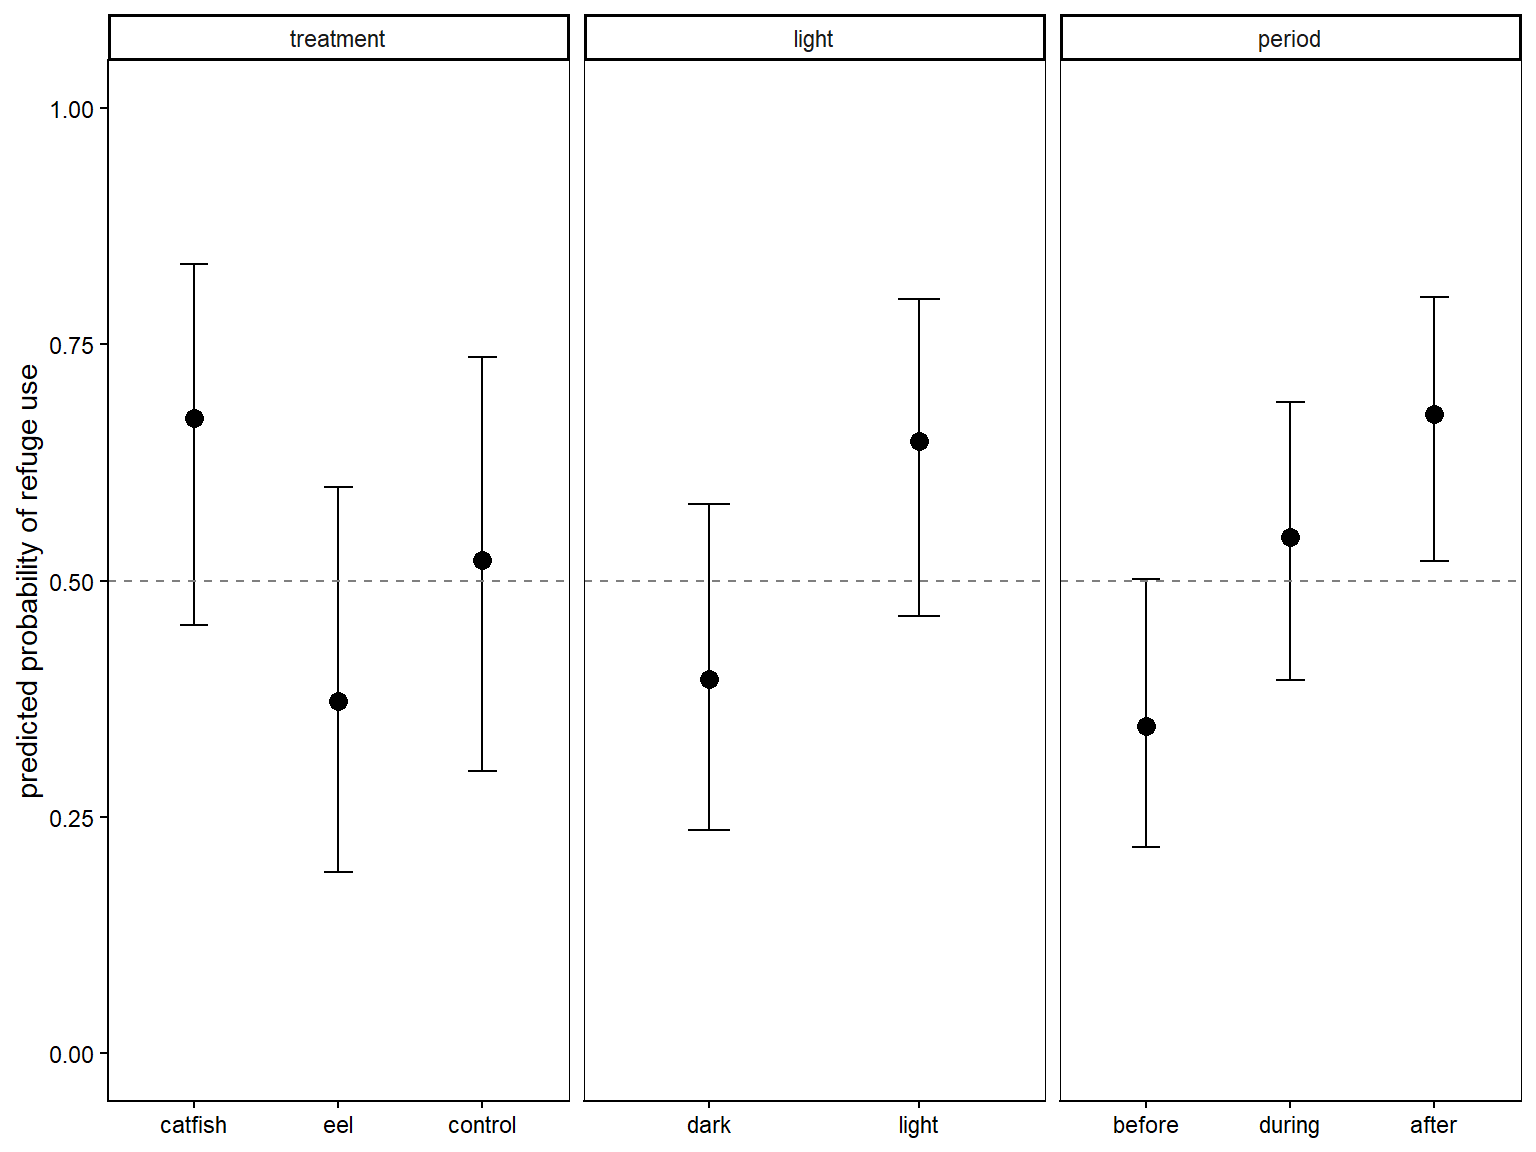

In [ ]:

# Make plot
# get predicted probabilities (not contrasts) for plotting
emm_treat_pred  <- as.data.frame(emmeans(m_final_bb, ~ treatment, type = "response"))
emm_period_pred <- as.data.frame(emmeans(m_final_bb, ~ period,    type = "response"))
emm_light_pred  <- as.data.frame(emmeans(m_final_bb, ~ light,     type = "response"))

# add factor label and rename x variable
emm_treat_pred  <- emm_treat_pred  %>% mutate(factor = "treatment", x = treatment)
emm_period_pred <- emm_period_pred %>% mutate(factor = "period",    x = period)
emm_light_pred  <- emm_light_pred  %>% mutate(factor = "light",     x = light)

emm_all <- bind_rows(emm_treat_pred, emm_period_pred, emm_light_pred) %>%
  mutate(factor = factor(factor, levels = c("treatment", "light", "period")),
         x = factor(x, levels = c("catfish", "eel", "control", "dark", "light", "before", "during", "after")))

emmeans_plot <- ggplot(emm_all, aes(x = x, y = prob, ymin = asymp.LCL, ymax = asymp.UCL)) +
  geom_point(size = 3) +
  geom_errorbar(width = 0.2) +
  facet_wrap(~ factor, scales = "free_x") +
  scale_y_continuous("predicted probability of refuge use", limits = c(0, 1)) +
  scale_x_discrete(NULL) +
  geom_hline(yintercept = 0.5, linetype = "dashed", colour = "grey50")

ggsave(file.path(out_dir, "emmeans_plot.png"), emmeans_plot, width = 5, height = 3, dpi = 300)
emmeans_plot


## Summary table of koura used

In [ ]:

grps <- list(c("treatment","light"), "treatment", "light", character(0))
tags <- c("treatment+light","treatment","light","overall")

summary_animals <- Map(function(g, tag)
  df_NCE_raw %>%
    group_by(across(all_of(g))) %>%
    summarise(n_trials = n(), mean_size = mean(size_mm1, na.rm=TRUE), sd_size = sd(size_mm1, na.rm=TRUE), min_size  = min(size_mm1, na.rm = TRUE), max_size = max(size_mm1, na.rm = TRUE), mean_weight = mean(weight_g1, na.rm=TRUE), sd_weight = sd(weight_g1,       na.rm=TRUE),min_weight = min(weight_g1, na.rm = TRUE),
      max_weight = max(weight_g1, na.rm = TRUE),.groups="drop") %>%
    mutate(grouping=tag) %>%
    { if(!"treatment"%in%g) mutate(., treatment="All") else . } %>%
    { if(!"light"%in%g)     mutate(., light="All")     else . },
  grps, tags) %>%
  bind_rows() %>%
  select(grouping, treatment, light, everything()) %>%
  arrange(factor(grouping, levels=tags), treatment, light)

# need to make into nice table
knitr::kable(summary_animals, digits = 2, 
             caption = "Summary of kōura used in experiments")


  ------------------------------------------------------------------------------------------------------------------------------------------------
  grouping          treatment   light     n_trials   mean_size   sd_size   min_size   max_size   mean_weight   sd_weight   min_weight   max_weight
  ----------------- ----------- ------- ---------- ----------- --------- ---------- ---------- ------------- ----------- ------------ ------------
  treatment+light   catfish     dark            11       25.99      2.97      21.46      30.28         11.64        4.06            6           19

  treatment+light   catfish     light           11       26.45      1.53      23.84      28.47         11.45        2.91            8           17

  treatment+light   control     dark            10       25.93      4.76      18.35      32.95         11.60        6.79            3           23

  treatment+light   control     light           10       26.17      1.86      23.71      29.97         11.50        2.88            9           17

  treatment+light   eel         dark            11       25.16      4.37      18.35      30.95         12.00        5.62            3           21

  treatment+light   eel         light           11       26.66      2.12      23.58      29.49         12.00        2.86            8           17

  treatment         catfish     All             22       26.22      2.32      21.46      30.28         11.55        3.45            6           19

  treatment         control     All             20       26.05      3.52      18.35      32.95         11.55        5.07            3           23

  treatment         eel         All             22       25.91      3.44      18.35      30.95         12.00        4.35            3           21

  light             All         dark            32       25.68      3.97      18.35      32.95         11.75        5.38            3           23

  light             All         light           32       26.44      1.81      23.58      29.97         11.66        2.80            8           17

  overall           All         All             64       26.06      3.08      18.35      32.95         11.70        4.25            3           23
  ------------------------------------------------------------------------------------------------------------------------------------------------

  : Summary of kōura used in experiments


## Plots individual koura

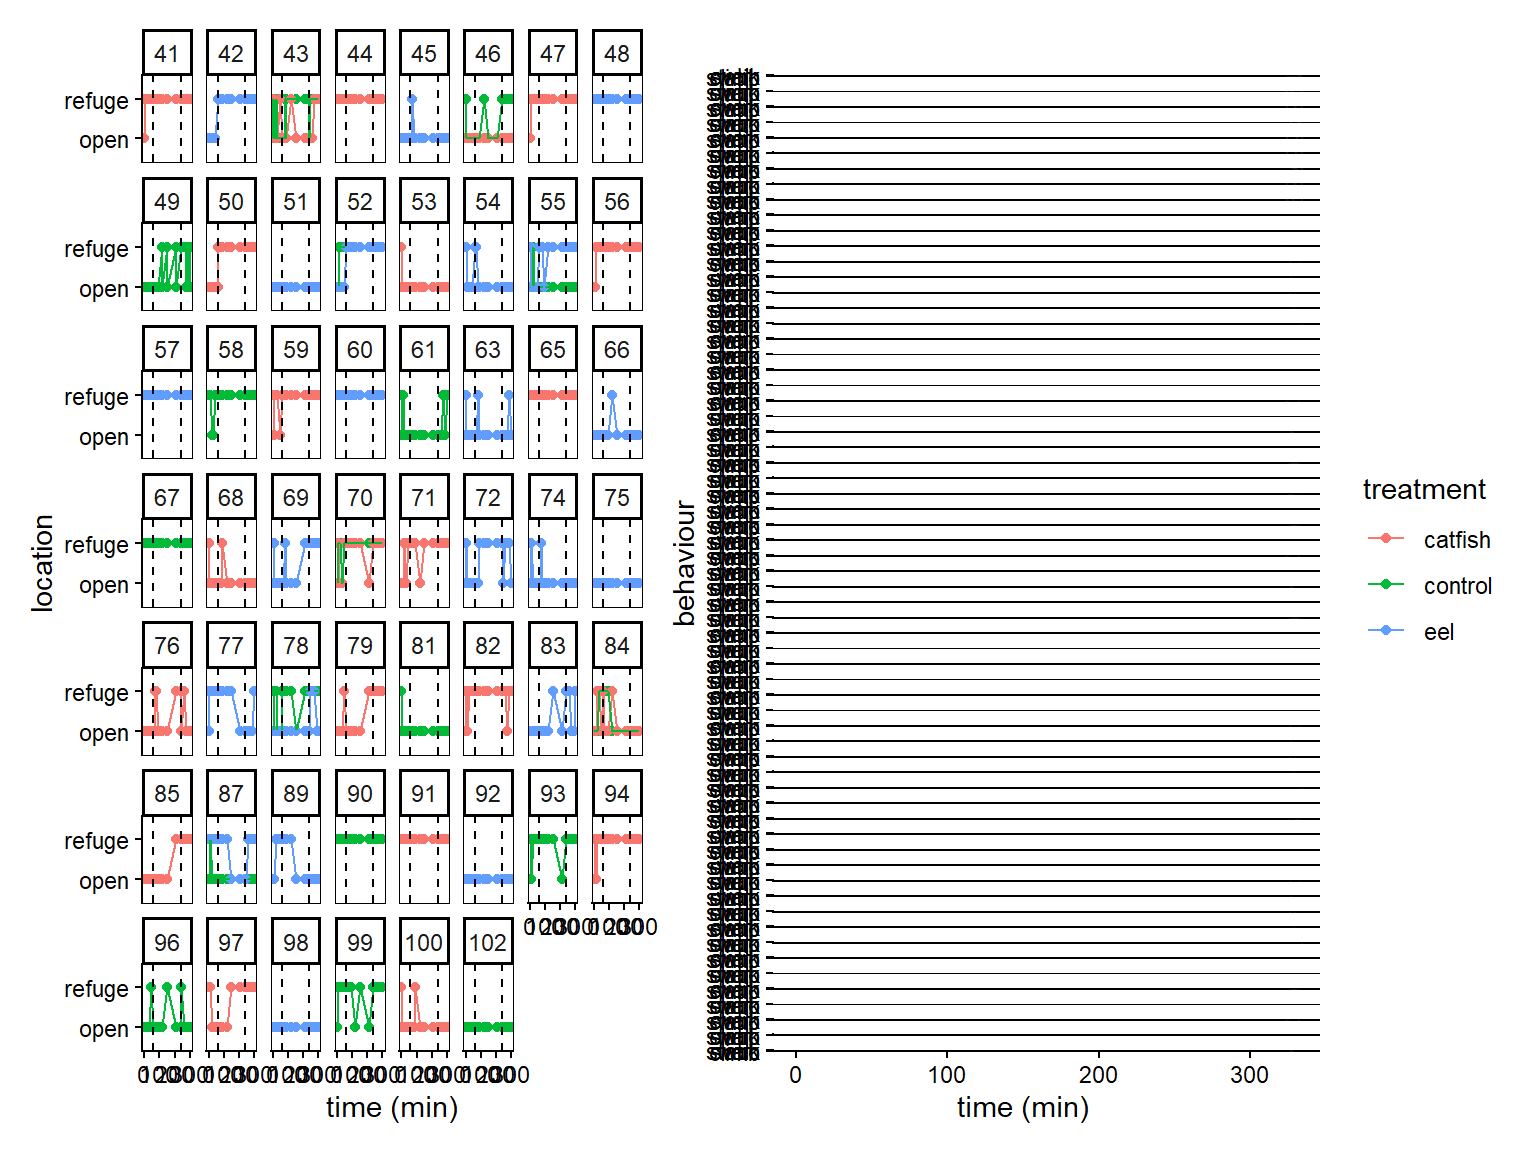

In [ ]:

loc_order <- c("ref_back","ref_open","ref_next","wall","floor","barrier")
beh_order <- c("static","walk","swim","climb")

koura_location_time <- koura_long %>%
  mutate(location = factor(location, levels = loc_order))

koura_behaviour_time <- koura_long %>%
  mutate(behaviour = factor(behaviour, levels = beh_order))

# --- Plots ---
p_loc_time <- ggplot(koura_long_ref, aes(time, location, col = treatment)) +
  geom_point() +  
  geom_line(aes(group = treatment)) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ .) +
  labs(x = "time (min)", y = "location") +
  theme(legend.position = "none")

p_beh_time <- ggplot(koura_long_ref, aes(time, behaviour, col = treatment)) +
  geom_point() +
  geom_line(aes(group = treatment))+
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_grid(exp_id ~ .) +
  labs(x = "time (min)", y = "behaviour") 

# --- Combine ---
koura_time_plot <- p_loc_time + p_beh_time
koura_time_plot


## Barrier

# A tibble: 9 × 3
  treatment period mean_prop
  <chr>     <fct>      <dbl>
1 catfish   before     0.348
2 catfish   during     0.298
3 catfish   after      0.235
4 control   before     0.383
5 control   during     0.422
6 control   after      0.275
7 eel       before     0.371
8 eel       during     0.369
9 eel       after      0.462

 Family: betabinomial  ( logit )
Formula:          
cbind(n_barrier, n_total - n_barrier) ~ treatment + light + period
Data: barrier_summary

      AIC       BIC    logLik -2*log(L)  df.resid 
    708.1     730.9    -347.1     694.1       185 


Dispersion parameter for betabinomial family (): 0.88 

Conditional model:
                 Estimate Std. Error z value Pr(>|z|)  
(Intercept)       -0.5811     0.2695  -2.156   0.0311 *
treatmentcontrol   0.3927     0.2879   1.364   0.1725  
treatmenteel       0.5374     0.2811   1.912   0.0559 .
lightlight        -0.3881     0.2316  -1.676   0.0938 .
periodduring      -0.1656     0.2691  -0.615   0.5384  
periodafter       -0.4717     0.2891  -1.632   0.1028  
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

 contrast          odds.ratio    SE  df null z.ratio p.value
 catfish / control      0.675 0.194 Inf    1  -1.364  0.3598
 catfish / eel          0.584 0.164 Inf    1  -1.912  0.1353
 control / eel          0.865 0.241 Inf    1  -0.519  0.8620

Results are averaged over the levels of: light, period 
P value adjustment: tukey method for comparing a family of 3 estimates 
Tests are performed on the log odds ratio scale 

 contrast        odds.ratio    SE  df null z.ratio p.value
 before / during       1.18 0.318 Inf    1   0.615  0.8118
 before / after        1.60 0.463 Inf    1   1.632  0.2323
 during / after        1.36 0.403 Inf    1   1.032  0.5564

Results are averaged over the levels of: treatment, light 
P value adjustment: tukey method for comparing a family of 3 estimates 
Tests are performed on the log odds ratio scale 


    DHARMa nonparametric dispersion test via sd of residuals fitted vs.
    simulated

data:  simulationOutput
dispersion = 1.0254, p-value = 0.8
alternative hypothesis: two.sided

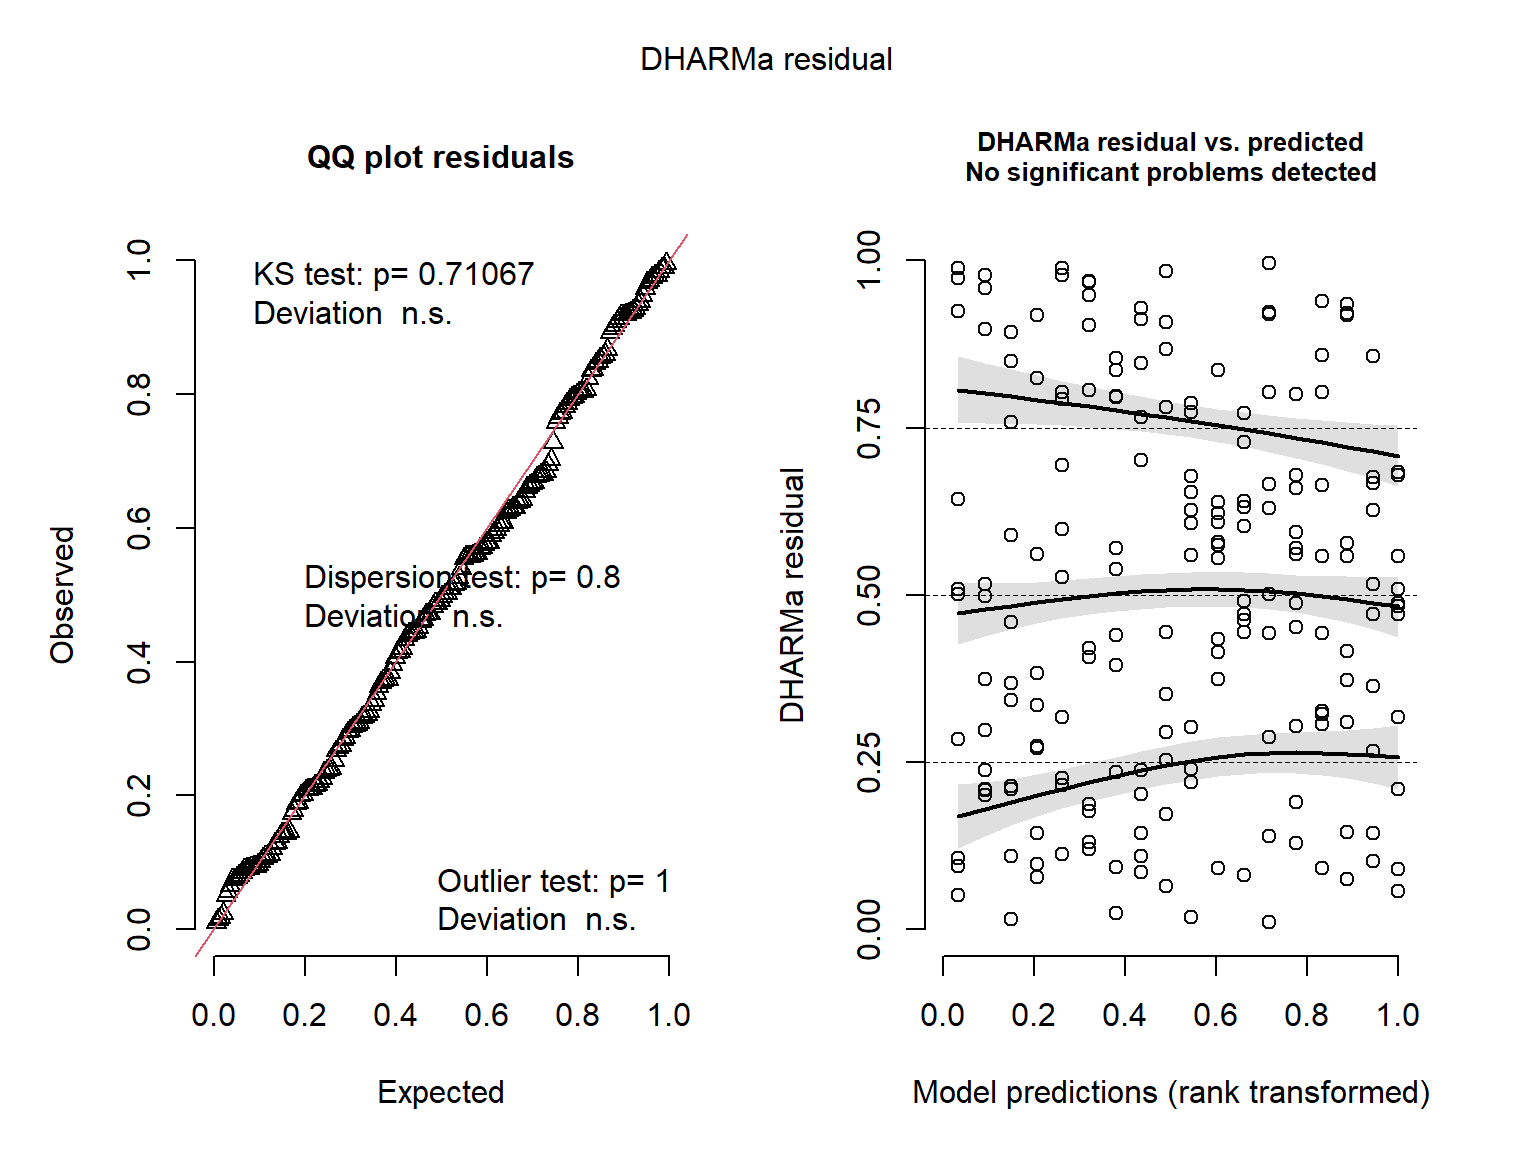

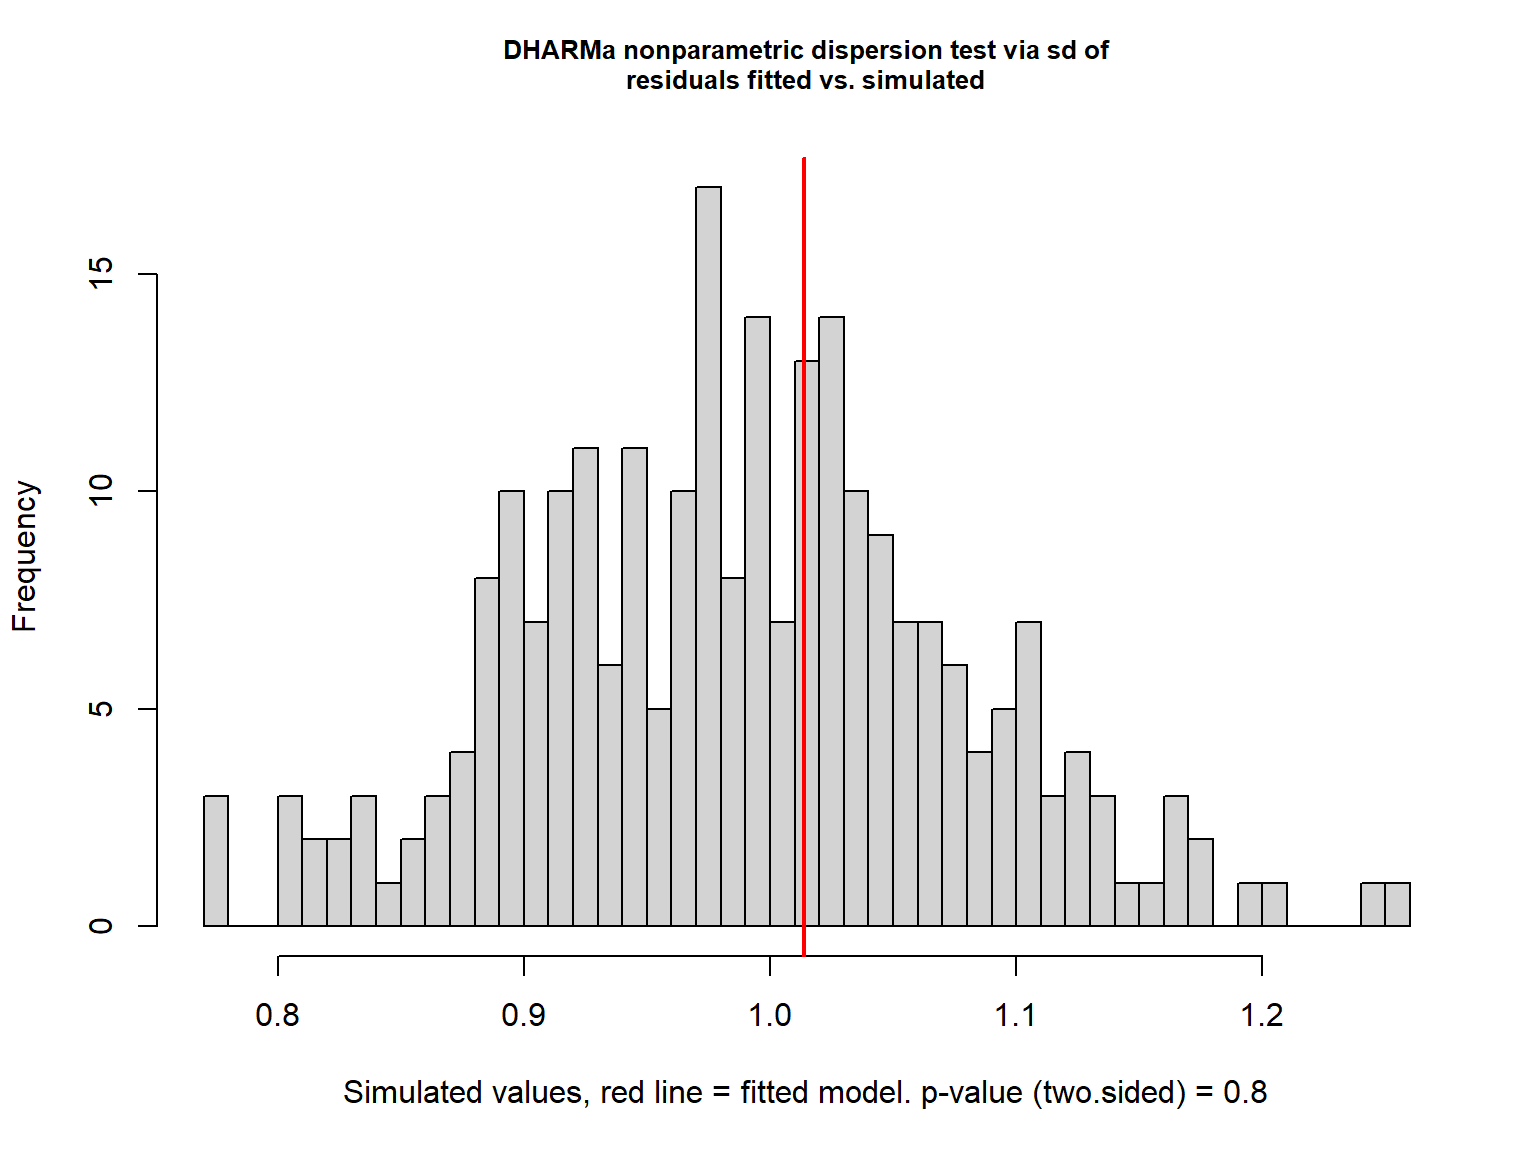

In [ ]:

koura_long_bar <- koura_long %>%
  mutate(location = case_when(
      location == "barrier" ~ "barrier",
      location %in% c("floor", "wall") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_ ),
    behaviour = case_when(
      behaviour == "climb" ~ "climbing",
      behaviour %in% c("static", "walk", "swim") ~ "other",
      TRUE ~ NA_character_))

# summarise barrier climbing per round
barrier_summary <- koura_long_bar %>%
  filter(!is.na(location)) %>%
  group_by(treatment, exp_id, round, tank, light, period) %>%
  summarise(
    n_total   = n(),
    n_barrier = sum(location == "barrier", na.rm = TRUE),
    .groups   = "drop"
  )

# check counts
barrier_summary %>%
  group_by(treatment, period) %>%
  summarise(mean_prop = mean(n_barrier/n_total), .groups = "drop")


# Feeding experiment

## Feeding plot

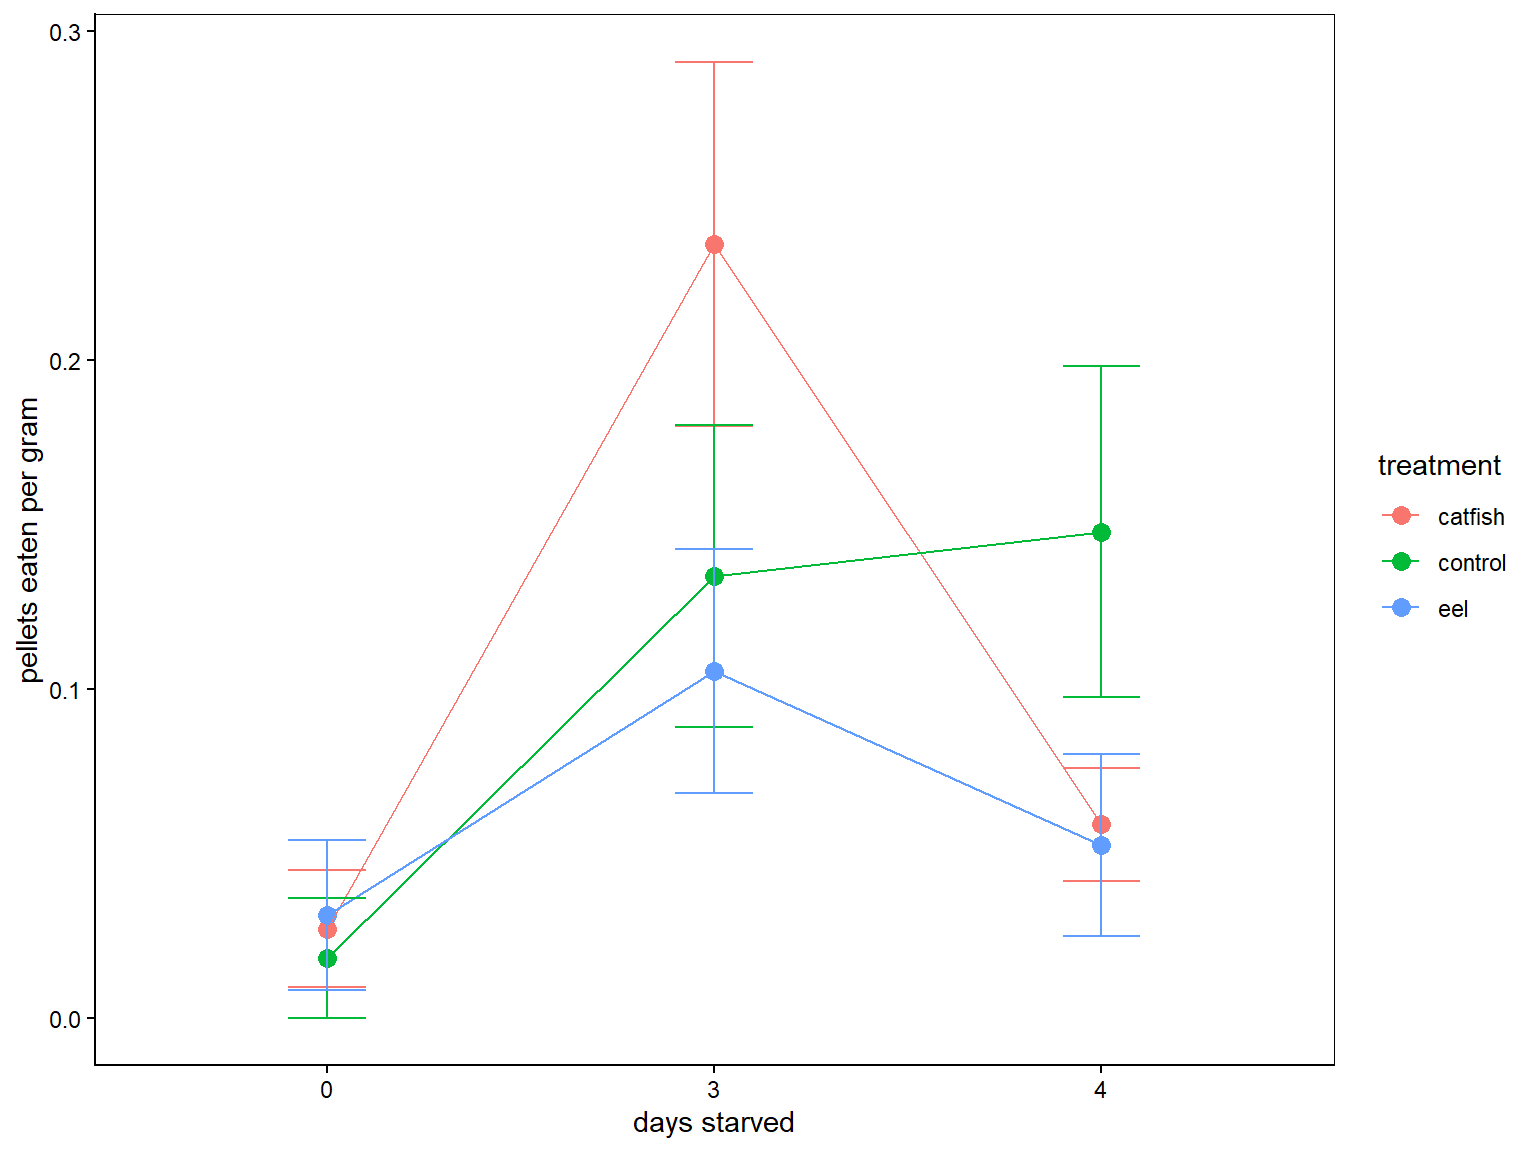

In [ ]:

df_feeding <- df_Feeding_raw %>%
  filter(round != 1) %>%
  mutate(pellets_eaten_24h = total_fed - left_after_24h,
    pellets_per_g = pellets_eaten_24h / weight_g1,
    koura_id = as.factor(koura_id),
    treatment = as.factor(treatment),
    day_starve = as.factor(day_starve))

feeding_plot <- ggplot(df_feeding, aes(day_starve, pellets_per_g, 
                        colour = treatment, group = treatment)) +
  stat_summary(fun = mean, geom = "point", size = 3) +
  stat_summary(fun = mean, geom = "line") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) +
  labs(x = "days starved", y = "pellets eaten per gram")

ggsave(file.path(out_dir, "feeding_plot.png"), feeding_plot, width = 8, height = 5, dpi = 300)

feeding_plot


## Feeding stats

Anova Table (Type III tests)

Response: pellets_per_g
                       Sum Sq Df F value    Pr(>F)    
(Intercept)          0.004401  1  0.6401 0.4285109    
treatment            0.000446  2  0.0325 0.9680855    
day_starve           0.131605  2  9.5709 0.0004152 ***
treatment:day_starve 0.061643  4  2.2415 0.0821411 .  
Residuals            0.268134 39                      
---
Signif. codes:  0 '***' 0.001 '**' 0.01 '*' 0.05 '.' 0.1 ' ' 1

 treatment day_starve emmean     SE df lower.CL upper.CL
 catfish   0          0.0271 0.0339 39  -0.0414   0.0956
 control   0          0.0182 0.0371 39  -0.0568   0.0932
 eel       0          0.0312 0.0371 39  -0.0438   0.1062
 catfish   3          0.2351 0.0371 39   0.1601   0.3101
 control   3          0.1342 0.0371 39   0.0592   0.2092
 eel       3          0.1052 0.0339 39   0.0367   0.1737
 catfish   4          0.0587 0.0371 39  -0.0163   0.1337
 control   4          0.1477 0.0339 39   0.0792   0.2162
 eel       4          0.0524 0.0371 39  -0.0226   0.1274

Confidence level used: 0.95 


    Shapiro-Wilk normality test

data:  residuals(lm_feed)
W = 0.97279, p-value = 0.324

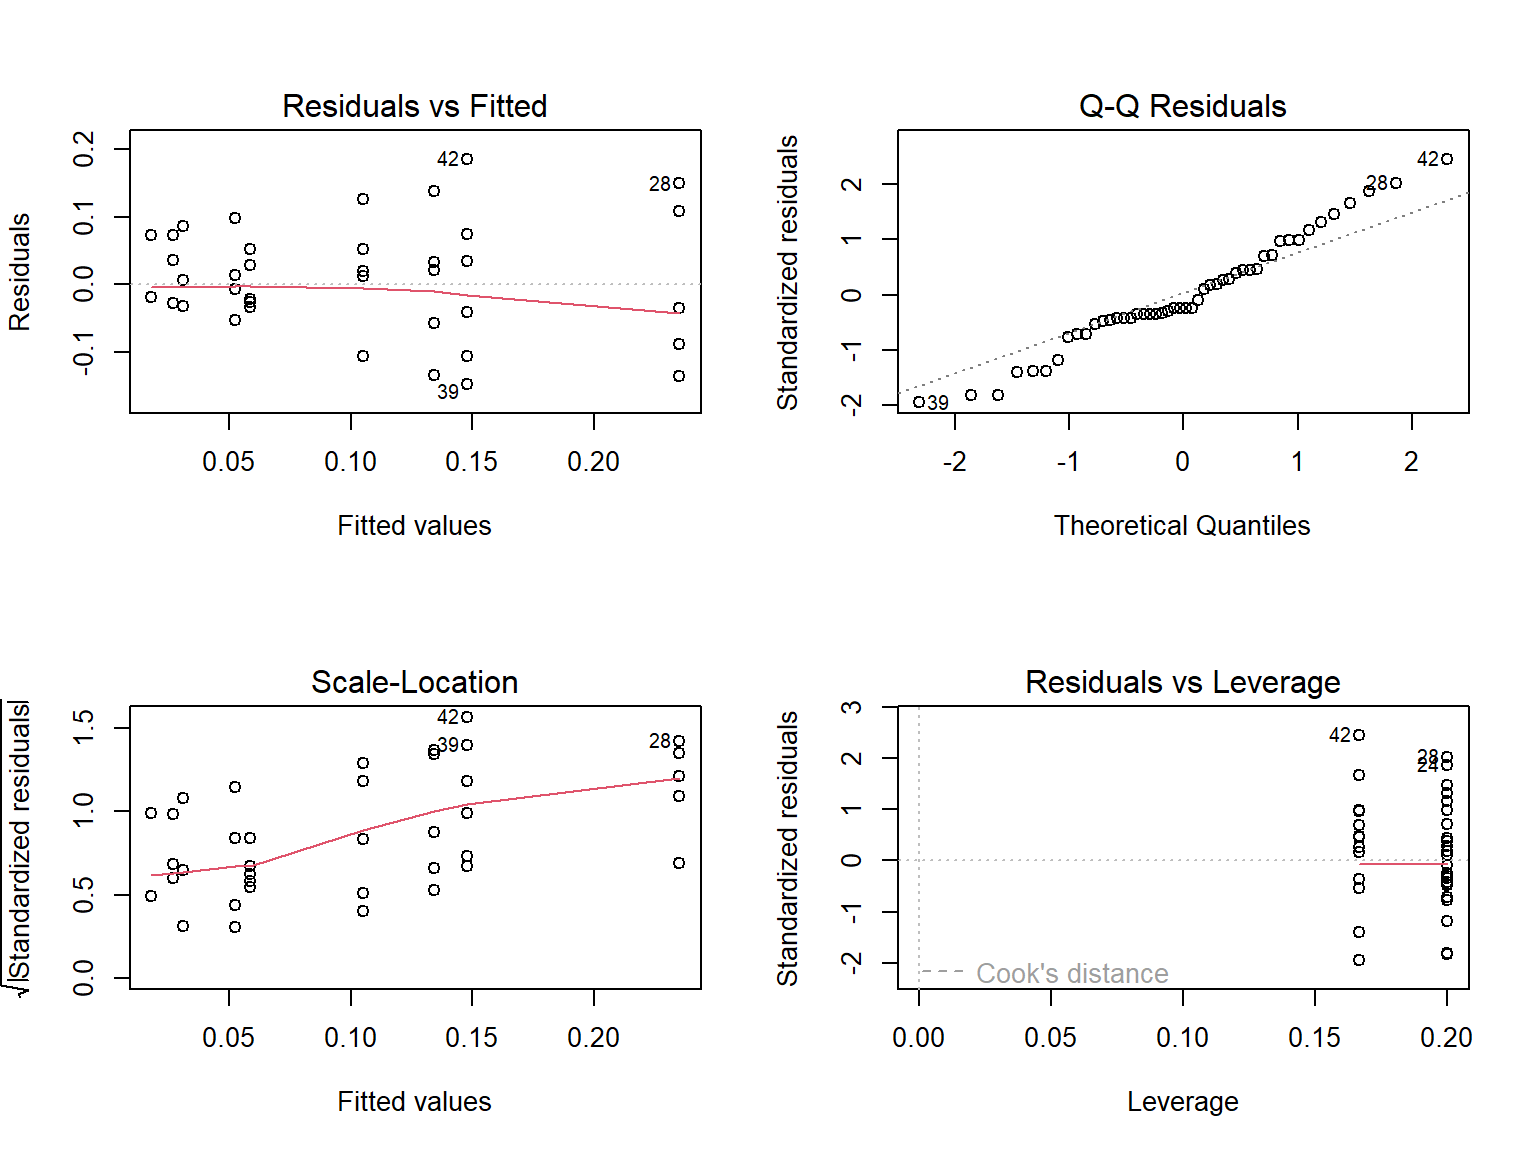

In [ ]:

# Model selection

feeding_models <- list(
  m1 = lm(pellets_per_g ~ treatment * day_starve, data = df_feeding),
  m2 = lm(pellets_per_g ~ treatment * day_starve + (1 | exp_id ), data = df_feeding),
  m3 = lm(pellets_per_g ~ treatment + day_starve, data = df_feeding),
  m4 = lm(pellets_per_g ~ treatment + day_starve + (1 | exp_id ), data = df_feeding),
  m5 = lm(pellets_per_g ~ day_starve + treatment, data = df_feeding),
  m6 = lm(pellets_per_g ~ treatment, data = df_feeding),
  m7 = lm(pellets_per_g ~ day_starve, data = df_feeding)
)

comparison_feeding_models <- data.frame(
  model  = names(feeding_models),
  AIC    = sapply(feeding_models, AIC),
  BIC    = sapply(feeding_models, BIC),
  logLik = sapply(feeding_models, \(m) as.numeric(logLik(m)))) |>
  arrange(AIC) |>
  mutate(delta_AIC = round(AIC - min(AIC), 2))

#print(comparison_feeding_models)


# Final Linear model
lm_feed <- lm(pellets_per_g ~ treatment * day_starve, data = df_feeding)

# extract p-values for inline reporting
anova_feed <- Anova(lm_feed, type = "III")
p_treatment    <- round(anova_feed["treatment", "Pr(>F)"], 3)
p_day_starve   <- round(anova_feed["day_starve", "Pr(>F)"], 4)
p_interaction  <- round(anova_feed["treatment:day_starve", "Pr(>F)"], 3)
p_shapiro_feed <- round(shapiro.test(residuals(lm_feed))$p.value, 3)

# emmeans for inline values
emm_feed_df <- as.data.frame(emmeans(lm_feed, ~ treatment * day_starve)) %>%
  mutate(across(where(is.numeric), round, 3))

get_emm <- function(trt, starve) {
  emm_feed_df %>% 
    filter(treatment == trt, day_starve == starve) %>% 
    pull(emmean)
}

get_se <- function(trt, starve) {
  emm_feed_df %>% 
    filter(treatment == trt, day_starve == starve) %>% 
    pull(SE)
}

Anova(lm_feed, type = "III")


```` markdown
---
title: "Analysis Notebook"
format: html
execute:
  freeze: false
  cache: false
---

# Setup
quarto-executable-code-5450563D

```r
#| label: setup
#| include: false

options(warn = -1)

packages <- c("DT","car","glmmTMB","AICcmodavg", "ggeffects","DHARMa", "brms", "emmeans", "lme4","lmerTest","vegan","ggnewscale","multcompView","patchwork","janitor","lubridate","stringr","tidyverse","dplyr","ggplot2","readxl","writexl","readr")

# Load packages if not already installed
quiet_load <- function(pkg) {
  if (!requireNamespace(pkg, quietly = TRUE)) {
    suppressWarnings(suppressMessages(install.packages(pkg, dependencies = TRUE)))}
  suppressPackageStartupMessages(require(pkg, character.only = TRUE, quietly = TRUE))
  invisible(TRUE)}

invisible(lapply(packages, quiet_load))

exc_file_dir <- "data/raw/NCE_data.xlsx"
der_data_dir <- "data/derived"
out_dir      <- "outputs"

# Read sheets from raw xlsx
df_NCE_raw <- readxl::read_excel(exc_file_dir, sheet = "NCE_exp")
df_Feeding_raw <- readxl::read_excel(exc_file_dir, sheet = "Feeding")

# Save as csv to derived/
write.csv(df_NCE_raw,     file.path(der_data_dir, "NCE_exp.csv"),  row.names = FALSE)
write.csv(df_Feeding_raw, file.path(der_data_dir, "Feeding.csv"),  row.names = FALSE)

df_NCE_raw     <- read.csv(file.path(der_data_dir, "NCE_exp.csv"))
df_Feeding_raw <- read.csv(file.path(der_data_dir, "Feeding.csv"))

# Set base for plots
base_theme_bw <- theme_classic() +
  theme(text     = element_text(family = "Arial", size = 11),
    axis.title   = element_text(face = "plain"),
    axis.text    = element_text(face = "plain"),
    plot.title   = element_text(face = "plain"),
    strip.text   = element_text(face = "plain"),
    panel.border = element_rect(colour = "black", fill = NA, linewidth = 0.3))
theme_set(base_theme_bw)

```

# Refuge experiment
## Build refuge dataframe
quarto-executable-code-5450563D

```r
#| label: build-df
#| include: false

df_NCE_raw <- df_NCE_raw %>%
  dplyr::select(-location_T180, -behaviour_T180)

# make into long format
koura_long <- df_NCE_raw %>%
  pivot_longer(
    cols = matches("^(location|behaviour)_"),
    names_to   = c(".value","time"),
    names_pattern = "(location|behaviour)_T?(\\d+)" ) %>%
  mutate(time = as.numeric(time))

koura_long <- koura_long %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

#Group all refuge used
koura_long_ref <- koura_long %>%
  mutate(
    location = case_when(
      location %in% c("floor", "wall", "barrier") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_))

koura_long_ref <- koura_long_ref %>%
  mutate(period = case_when(
    time < 60 ~ "before",
    time >= 60 & time < 240 ~ "during",
    time >= 240 ~ "after",
    TRUE ~ NA_character_))%>%
  mutate(period = factor(period, levels = c("before", "during", "after")))

```

## Refuge table
quarto-executable-code-5450563D

```r
#| label: tbl-refuge
#| include: true
#| tbl-cap: "Proportion of kōura observations recorded in refuge across experimental treatments (catfish, eel, control), light conditions (light, dark), and periods (before, during, and after predator exposure). Combined rows summarise across all levels of a given factor. Values represent the proportion of total observations where kōura were located in the refuge."

prop_refuge_light_treat <- koura_long_ref %>%
  dplyr::group_by(light, treatment, period) %>%
  dplyr::summarise(
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_treat <- koura_long_ref %>%
  dplyr::group_by(treatment, period) %>%
  dplyr::summarise(light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_light <- koura_long_ref %>%
  dplyr::group_by(light, period) %>%
  dplyr::summarise(treatment = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_per <- koura_long_ref %>%
  dplyr::group_by(period) %>%
  dplyr::summarise(treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

prop_refuge_comb <- koura_long_ref %>%
  dplyr::summarise(period = "combined",
    treatment = "combined",
    light = "combined",
    n_total  = dplyr::n(),
    n_refuge = sum(location == "refuge", na.rm = TRUE),
    prop_refuge = n_refuge / n_total,.groups = "drop")

refuge_table <- dplyr::bind_rows(prop_refuge_light_treat, prop_refuge_treat,prop_refuge_light, prop_refuge_per, prop_refuge_comb) %>%
  mutate_if(is.numeric, round, digits = 2)

# extract specific values for inline reporting
get_prop <- function(l, t, p) {
  refuge_table %>% 
    filter(light == l, treatment == t, period == p) %>% 
    pull(prop_refuge)
}

write.csv(refuge_table, file = file.path(out_dir, "refuge_table.csv"), row.names = FALSE)

if (knitr::is_html_output()) {
  datatable(
    refuge_table,
    caption = "Proportion of kōura observations recorded in refuge across experimental treatments (catfish, eel, control), light conditions (light, dark), and periods (before, during, and after predator exposure). Combined rows summarise across all levels of a given factor. Values represent the proportion of total observations where kōura were located in the refuge.",
    filter = "top",
    options = list(
      pageLength = 37,
      dom = 'Bfrtip',
      buttons = c('csv', 'excel'),
      columnDefs = list(list(className = 'dt-center', targets = "_all"))
    ),
    extensions = 'Buttons',
    rownames = FALSE,
    colnames = c("Light", "Treatment", "Period", "N total", "N refuge", "Proportion in refuge")
  ) |>
    formatRound(columns = "prop_refuge", digits = 2) |>
    formatStyle(
      "prop_refuge",
      background = styleColorBar(range(refuge_table$prop_refuge), "lightblue"),
      backgroundSize = "100% 90%",
      backgroundRepeat = "no-repeat",
      backgroundPosition = "center"
    )
} else {
  knitr::kable(refuge_table, digits = 2,
    caption = "Proportion of kōura observations in refuge by treatment, light condition and period")
}

```

## Refuge plot
quarto-executable-code-5450563D

```r
#| label: fig-refuge-plot
#| include: true
#| fig-cap: "Kōura use of refuge over course of experiment with the three periods (before, during, after), the treatment (catfish; red-solid circle, eel; green-dashed triangle, control; blue-dotdash square), and divided over light regime (combined, dark, light). The points represent the proportion within each period for each treatment."

loc_order_ref <- c("refuge","open")

# calculate the proportions of location for each treatment for each time step
prop_location_time <- koura_long_ref %>%
  filter(!is.na(location), location != "") %>%
  count(treatment, time, light, location = location, name = "n") %>%
  group_by(treatment, time, light) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(treatment = factor(treatment, levels = c("catfish","eel","control")),
    location  = factor(location,  levels = loc_order_ref))

# Create combined light data
prop_location_time_combined <- prop_location_time %>%
  group_by(treatment, time, location) %>%
  summarise(n = sum(n), .groups = "drop") %>%
  group_by(treatment, time) %>%
  mutate(prop = n / sum(n)) %>%
  ungroup() %>%
  mutate(light = "combined")

period_x <- c("before" = 30, "during" = 150, "after" = 270)

prop_overlay <- prop_refuge_light_treat %>%
  mutate(time = period_x[period], treatment = factor(treatment, levels = c("catfish", "eel", "control")))

prop_overlay_combined <- prop_refuge_treat %>%
  mutate(time = period_x[period], 
         treatment = factor(treatment, levels = c("catfish", "eel", "control")))

# Bind combined with separated
plot_data <- bind_rows(prop_location_time, prop_location_time_combined) %>%
  mutate(light = factor(light, levels = c("combined", "dark", "light")))

overlay_data <- bind_rows(prop_overlay, prop_overlay_combined) %>%
  mutate(light = factor(light, levels = c("combined", "dark", "light")))

refuge_plot <- plot_data %>%
  dplyr::filter(location == "refuge") %>%
  ggplot2::ggplot(aes(time, prop, colour = treatment, group = treatment, linetype = treatment)) +
  geom_line(linewidth = 1) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  geom_vline(xintercept = c(0, 5, 10, 20, 30, 45, 60, 61, 65, 70, 80, 90, 120, 150, 210, 240, 245, 260, 275, 290, 300), alpha = .15) +
  geom_point(data = overlay_data,  aes(x = time, y = prop_refuge, fill = treatment, shape = treatment), stroke = 1, col = "black") +
  annotate("text", x = 30,  y = 1, label = "before", size = 3) +
  annotate("text", x = 150, y = 1, label = "during", size = 3) +
  annotate("text", x = 270, y = 1, label = "after",  size = 3) +
  scale_linetype_manual(values = c("solid", "dashed", "dotdash")) +
  scale_shape_manual(values = c(21, 24, 22)) +
  facet_grid(light ~ ., scales = "free_x") +
  labs(x = NULL, y = "proportion in refuge", 
       colour = "treatment", linetype = "treatment", shape = "treatment")

ggsave(file.path(out_dir, "refuge_plot.png"), refuge_plot, width = 8, height = 5, dpi = 300)

refuge_plot

```

## Refuge stats
quarto-executable-code-5450563D

```r
#| label: refuge-stats
#| include: false


koura_stat <- koura_long_ref %>%
  select(treatment, exp_id, round, tank, time, period, light, location, koura_id) %>%
  mutate(
    location = factor(location, levels = c("refuge", "open")),
    period   = factor(period,   levels = c("before", "during", "after")),
    tank     = factor(tank))

round_summary <- koura_stat %>%
  group_by(treatment, exp_id, round, tank, light, period, koura_id) %>%
  summarise(
    n_total  = n(),
    n_refuge = sum(location == "refuge"),
    .groups  = "drop")

# Model selection
models_bb <- list(
  m1_full = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m2_twoway = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * light + treatment * period + light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m3_trt_period = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment * period + light + (1 | tank),
    data = round_summary, family = betabinomial),
  m4_light_period = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light * period + (1 | tank),
    data = round_summary, family = betabinomial),
  m5_tank = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | tank),
    data = round_summary, family = betabinomial),
  m6_exp_id = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | exp_id),
    data = round_summary, family = betabinomial),
  m7_koura_id = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | koura_id),
    data = round_summary, family = betabinomial),
  m8_main = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period,
    data = round_summary, family = betabinomial),
  m9_null = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ 1 + (1 | tank),
    data = round_summary, family = betabinomial),
  m10_both = glmmTMB(
    cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | koura_id) + (1 | exp_id),
    data = round_summary, family = betabinomial))

comparison_bb <- data.frame(
  model  = names(models_bb),
  AIC    = sapply(models_bb, AIC),
  BIC    = sapply(models_bb, BIC),
  logLik = sapply(models_bb, \(m) as.numeric(logLik(m)))) |>
  arrange(AIC) |>
  mutate(delta_AIC = round(AIC - min(AIC), 2))

#print(comparison_bb)

# Final model (no random effect needed — AIC confirmed) 
m_final_bb <- glmmTMB(
  cbind(n_refuge, n_total - n_refuge) ~ treatment + light + period + (1 | exp_id),
  data = round_summary, family = betabinomial)

#summary(m_final_bb)

# Model diagnostics 
#sim_final <- simulateResiduals(m_final_bb)
#plot(sim_final)
#testDispersion(sim_final)
#testZeroInflation(sim_final)

# Marginal means and pairwise contrasts 
emm_treatment <- as.data.frame(pairs(emmeans(m_final_bb, ~ treatment, type = "response"))) %>% mutate(factor = "treatment")
emm_period    <- as.data.frame(pairs(emmeans(m_final_bb, ~ period,    type = "response"))) %>% mutate(factor = "period")
emm_light     <- as.data.frame(pairs(emmeans(m_final_bb, ~ light,     type = "response"))) %>% mutate(factor = "light")

emmeans_bb <- bind_rows(emm_treatment, emm_period, emm_light) %>%
  mutate(across(where(is.numeric), round, 3))

# Save fixed effects table 
fixed_bb <- as.data.frame(summary(m_final_bb)$coefficients$cond) %>%
  rownames_to_column("term") %>%
  mutate(across(where(is.numeric), round, 3))

write.csv(fixed_bb,    file.path(out_dir, "table_bb_fixed_effects.csv"), row.names = FALSE)
write.csv(emmeans_bb,  file.path(out_dir, "table_bb_emmeans.csv"),        row.names = FALSE)

# extract specific p-values for inline reporting
p_catfish_eel     <- emmeans_bb %>% filter(contrast == "catfish / eel")     %>% pull(p.value)
p_catfish_control <- emmeans_bb %>% filter(contrast == "catfish / control") %>% pull(p.value)
p_control_eel     <- emmeans_bb %>% filter(contrast == "control / eel")     %>% pull(p.value)
p_before_after    <- emmeans_bb %>% filter(contrast == "before / after")    %>% pull(p.value)
p_before_during   <- emmeans_bb %>% filter(contrast == "before / during")   %>% pull(p.value)
p_during_after    <- emmeans_bb %>% filter(contrast == "during / after")    %>% pull(p.value)
p_dark_light      <- emmeans_bb %>% filter(contrast == "dark / light")      %>% pull(p.value)



```

## Emmeans plot
quarto-executable-code-5450563D

```r
#| label: fig-emmeans-plot
#| include: true
#| fig-cap: "Predicted probability of refuge use with 95% confidence intervals. The dashed line at 0.5 helps show whether kōura spend more or less than half their time in refuge."

# Make plot
# get predicted probabilities (not contrasts) for plotting
emm_treat_pred  <- as.data.frame(emmeans(m_final_bb, ~ treatment, type = "response"))
emm_period_pred <- as.data.frame(emmeans(m_final_bb, ~ period,    type = "response"))
emm_light_pred  <- as.data.frame(emmeans(m_final_bb, ~ light,     type = "response"))

# add factor label and rename x variable
emm_treat_pred  <- emm_treat_pred  %>% mutate(factor = "treatment", x = treatment)
emm_period_pred <- emm_period_pred %>% mutate(factor = "period",    x = period)
emm_light_pred  <- emm_light_pred  %>% mutate(factor = "light",     x = light)

emm_all <- bind_rows(emm_treat_pred, emm_period_pred, emm_light_pred) %>%
  mutate(factor = factor(factor, levels = c("treatment", "light", "period")),
         x = factor(x, levels = c("catfish", "eel", "control", "dark", "light", "before", "during", "after")))

emmeans_plot <- ggplot(emm_all, aes(x = x, y = prob, ymin = asymp.LCL, ymax = asymp.UCL)) +
  geom_point(size = 3) +
  geom_errorbar(width = 0.2) +
  facet_wrap(~ factor, scales = "free_x") +
  scale_y_continuous("predicted probability of refuge use", limits = c(0, 1)) +
  scale_x_discrete(NULL) +
  geom_hline(yintercept = 0.5, linetype = "dashed", colour = "grey50")

ggsave(file.path(out_dir, "emmeans_plot.png"), emmeans_plot, width = 5, height = 3, dpi = 300)
emmeans_plot

```

## Summary table of koura used
quarto-executable-code-5450563D

```r
#| label: tbl-koura
#| include: true
#| tbl-cap: "your caption"


grps <- list(c("treatment","light"), "treatment", "light", character(0))
tags <- c("treatment+light","treatment","light","overall")

summary_animals <- Map(function(g, tag)
  df_NCE_raw %>%
    group_by(across(all_of(g))) %>%
    summarise(n_trials = n(), mean_size = mean(size_mm1, na.rm=TRUE), sd_size = sd(size_mm1, na.rm=TRUE), min_size  = min(size_mm1, na.rm = TRUE), max_size = max(size_mm1, na.rm = TRUE), mean_weight = mean(weight_g1, na.rm=TRUE), sd_weight = sd(weight_g1,       na.rm=TRUE),min_weight = min(weight_g1, na.rm = TRUE),
      max_weight = max(weight_g1, na.rm = TRUE),.groups="drop") %>%
    mutate(grouping=tag) %>%
    { if(!"treatment"%in%g) mutate(., treatment="All") else . } %>%
    { if(!"light"%in%g)     mutate(., light="All")     else . },
  grps, tags) %>%
  bind_rows() %>%
  select(grouping, treatment, light, everything()) %>%
  arrange(factor(grouping, levels=tags), treatment, light)

# need to make into nice table
knitr::kable(summary_animals, digits = 2, 
             caption = "Summary of kōura used in experiments")

```

## Plots individual koura
quarto-executable-code-5450563D

```r
#| label: fig-koura
#| include: true
#| fig-cap: "your caption"


loc_order <- c("ref_back","ref_open","ref_next","wall","floor","barrier")
beh_order <- c("static","walk","swim","climb")

koura_location_time <- koura_long %>%
  mutate(location = factor(location, levels = loc_order))

koura_behaviour_time <- koura_long %>%
  mutate(behaviour = factor(behaviour, levels = beh_order))

# --- Plots ---
p_loc_time <- ggplot(koura_long_ref, aes(time, location, col = treatment)) +
  geom_point() +  
  geom_line(aes(group = treatment)) +
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_wrap(koura_id ~ .) +
  labs(x = "time (min)", y = "location") +
  theme(legend.position = "none")

p_beh_time <- ggplot(koura_long_ref, aes(time, behaviour, col = treatment)) +
  geom_point() +
  geom_line(aes(group = treatment))+
  geom_vline(xintercept = c(60, 240), linetype = "dashed") +
  facet_grid(exp_id ~ .) +
  labs(x = "time (min)", y = "behaviour") 

# --- Combine ---
koura_time_plot <- p_loc_time + p_beh_time
koura_time_plot

```

## Barrier
quarto-executable-code-5450563D

```r
#| label: fig-barrier
#| include: true
#| fig-cap: "your caption"

koura_long_bar <- koura_long %>%
  mutate(location = case_when(
      location == "barrier" ~ "barrier",
      location %in% c("floor", "wall") ~ "open",
      location %in% c("ref_back", "ref_open", "ref_next") ~ "refuge",
      TRUE ~ NA_character_ ),
    behaviour = case_when(
      behaviour == "climb" ~ "climbing",
      behaviour %in% c("static", "walk", "swim") ~ "other",
      TRUE ~ NA_character_))

# summarise barrier climbing per round
barrier_summary <- koura_long_bar %>%
  filter(!is.na(location)) %>%
  group_by(treatment, exp_id, round, tank, light, period) %>%
  summarise(
    n_total   = n(),
    n_barrier = sum(location == "barrier", na.rm = TRUE),
    .groups   = "drop"
  )

# check counts
barrier_summary %>%
  group_by(treatment, period) %>%
  summarise(mean_prop = mean(n_barrier/n_total), .groups = "drop")

# fit model
m_barrier <- glmmTMB(
  cbind(n_barrier, n_total - n_barrier) ~ treatment + light + period,
  data = barrier_summary,
  family = betabinomial)

summary(m_barrier)

# emmeans contrasts
pairs(emmeans(m_barrier, ~ treatment, type = "response"))
pairs(emmeans(m_barrier, ~ period, type = "response"))

# DHARMa diagnostics
sim_bar <- simulateResiduals(m_barrier)
plot(sim_bar)
testDispersion(sim_bar)



```

# Feeding experiment
## Feeding plot
quarto-executable-code-5450563D

```r
#| label: fig-feeding-plot
#| include: true
#| fig-cap: "Mean kōura feeding rate (pellets consumed per gram body weight ± SE) across predator treatments (catfish, eel, control) and starvation periods (0, 3, and 4 days). Points represent treatment means and error bars show standard error."

df_feeding <- df_Feeding_raw %>%
  filter(round != 1) %>%
  mutate(pellets_eaten_24h = total_fed - left_after_24h,
    pellets_per_g = pellets_eaten_24h / weight_g1,
    koura_id = as.factor(koura_id),
    treatment = as.factor(treatment),
    day_starve = as.factor(day_starve))

feeding_plot <- ggplot(df_feeding, aes(day_starve, pellets_per_g, 
                        colour = treatment, group = treatment)) +
  stat_summary(fun = mean, geom = "point", size = 3) +
  stat_summary(fun = mean, geom = "line") +
  stat_summary(fun.data = mean_se, geom = "errorbar", width = 0.2) +
  labs(x = "days starved", y = "pellets eaten per gram")

ggsave(file.path(out_dir, "feeding_plot.png"), feeding_plot, width = 8, height = 5, dpi = 300)

feeding_plot
```

## Feeding stats
quarto-executable-code-5450563D

```r
#| label: feeding-stats
#| include: false

# Model selection

feeding_models <- list(
  m1 = lm(pellets_per_g ~ treatment * day_starve, data = df_feeding),
  m2 = lm(pellets_per_g ~ treatment * day_starve + (1 | exp_id ), data = df_feeding),
  m3 = lm(pellets_per_g ~ treatment + day_starve, data = df_feeding),
  m4 = lm(pellets_per_g ~ treatment + day_starve + (1 | exp_id ), data = df_feeding),
  m5 = lm(pellets_per_g ~ day_starve + treatment, data = df_feeding),
  m6 = lm(pellets_per_g ~ treatment, data = df_feeding),
  m7 = lm(pellets_per_g ~ day_starve, data = df_feeding)
)

comparison_feeding_models <- data.frame(
  model  = names(feeding_models),
  AIC    = sapply(feeding_models, AIC),
  BIC    = sapply(feeding_models, BIC),
  logLik = sapply(feeding_models, \(m) as.numeric(logLik(m)))) |>
  arrange(AIC) |>
  mutate(delta_AIC = round(AIC - min(AIC), 2))

#print(comparison_feeding_models)


# Final Linear model
lm_feed <- lm(pellets_per_g ~ treatment * day_starve, data = df_feeding)

# extract p-values for inline reporting
anova_feed <- Anova(lm_feed, type = "III")
p_treatment    <- round(anova_feed["treatment", "Pr(>F)"], 3)
p_day_starve   <- round(anova_feed["day_starve", "Pr(>F)"], 4)
p_interaction  <- round(anova_feed["treatment:day_starve", "Pr(>F)"], 3)
p_shapiro_feed <- round(shapiro.test(residuals(lm_feed))$p.value, 3)

# emmeans for inline values
emm_feed_df <- as.data.frame(emmeans(lm_feed, ~ treatment * day_starve)) %>%
  mutate(across(where(is.numeric), round, 3))

get_emm <- function(trt, starve) {
  emm_feed_df %>% 
    filter(treatment == trt, day_starve == starve) %>% 
    pull(emmean)
}

get_se <- function(trt, starve) {
  emm_feed_df %>% 
    filter(treatment == trt, day_starve == starve) %>% 
    pull(SE)
}

Anova(lm_feed, type = "III")
emmeans(lm_feed, ~ treatment * day_starve)
shapiro.test(residuals(lm_feed))
par(mfrow = c(2, 2))
plot(lm_feed)
par(mfrow = c(1, 1)) 


```


````